In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing Libaries

In [2]:
import os
folder_path = '/content/drive/MyDrive/MAJOR_PROJECT'
os.makedirs(folder_path, exist_ok=True)

In [ ]:
notebook_source = '/content/drive/MyDrive/Colab Notebooks/2_Data_Descriptor.ipynb'
notebook_dest = os.path.join(folder_path, '2_Data_Descriptor.ipynb')

!cp "{notebook_source}" "{notebook_dest}"
print(f"Notebook saved to: {notebook_dest}")

Notebook saved to: /content/drive/MyDrive/MAJOR_PROJECT/2_Data_Descriptor.ipynb


## Install rdkit

In [3]:
!pip install numpy==1.23.5
!pip install rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 52.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 56.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/GLP_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL410972,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,14.00,active
1,CHEMBL265428,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,5354.00,intermediate
2,CHEMBL439104,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,713.00,active
3,CHEMBL409873,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,454.00,active
4,CHEMBL410973,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,804.00,active
...,...,...,...,...
249,CHEMBL540612,COc1ccccc1N1CCN(CCCCNC(=O)c2ccc3ccccc3c2)CC1.Cl,10000.00,inactive
250,CHEMBL2164551,N#Cc1cc(F)cc(-c2nc(-c3ccc(F)cn3)no2)c1,10000.00,inactive
251,CHEMBL2018969,COc1cccc2c1c(NS(=O)(=O)c1ccc(Cl)s1)nn2Cc1cccc(...,10000.00,inactive
252,CHEMBL5075931,NCCc1cn(S(=O)(=O)c2c(Cl)nc3sccn23)c2ccccc12.O=...,3021.68,intermediate


In [6]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [7]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [8]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL410972,14.00,active,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...
1,CHEMBL265428,5354.00,intermediate,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...
2,CHEMBL439104,713.00,active,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...
3,CHEMBL409873,454.00,active,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...
4,CHEMBL410973,804.00,active,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...
...,...,...,...,...
249,CHEMBL540612,10000.00,inactive,COc1ccccc1N1CCN(CCCCNC(=O)c2ccc3ccccc3c2)CC1
250,CHEMBL2164551,10000.00,inactive,N#Cc1cc(F)cc(-c2nc(-c3ccc(F)cn3)no2)c1
251,CHEMBL2018969,10000.00,inactive,COc1cccc2c1c(NS(=O)(=O)c1ccc(Cl)s1)nn2Cc1cccc(...
252,CHEMBL5075931,3021.68,intermediate,NCCc1cn(S(=O)(=O)c2c(Cl)nc3sccn23)c2ccccc12


### Calculate Lipinski descriptors

In [9]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [10]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [11]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,3297.682,-13.99983,49.0,46.0
1,3593.961,-15.58750,49.0,51.0
2,3635.058,-14.45080,49.0,51.0
3,3594.005,-14.72400,49.0,51.0
4,3593.961,-15.58750,49.0,51.0
...,...,...,...,...
249,417.553,4.18060,1.0,4.0
250,284.225,2.94848,0.0,5.0
251,549.074,3.99600,3.0,7.0
252,380.882,2.74210,1.0,5.0


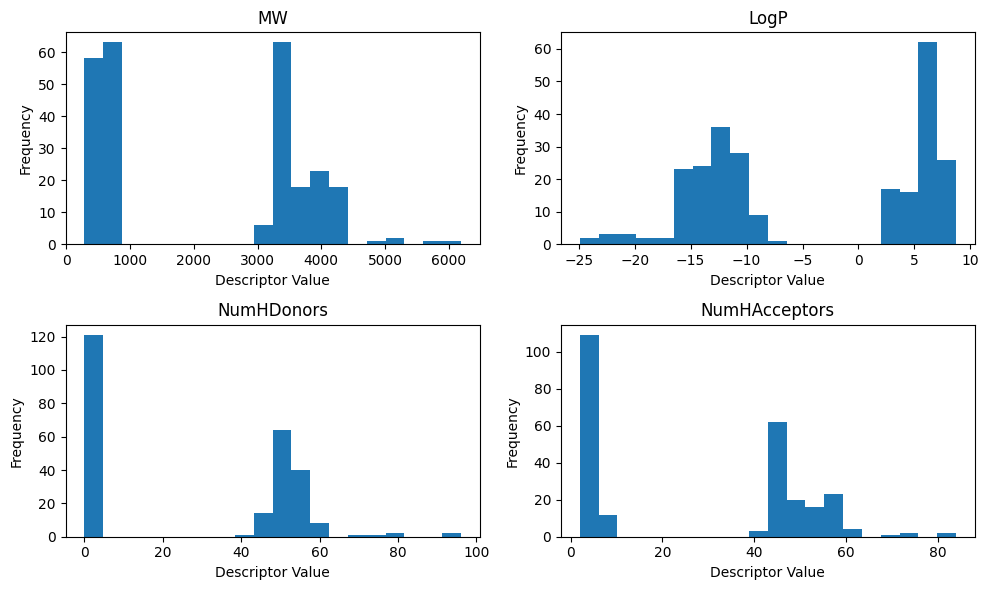

In [13]:
import matplotlib.pyplot as plt

axes = df_lipinski.hist(bins=20, figsize=(10,6), grid=False)

# Set axis labels
for ax in axes.flatten():
    ax.set_xlabel("Descriptor Value")   # X-axis
    ax.set_ylabel("Frequency")          # Y-axis

plt.tight_layout()
plt.show()


### Combine DataFrames

In [14]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [ ]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL410972,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,14.00,active,3297.682,-13.99983,49.0,46.0
1,CHEMBL265428,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,5354.00,intermediate,3593.961,-15.58750,49.0,51.0
2,CHEMBL439104,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,713.00,active,3635.058,-14.45080,49.0,51.0
3,CHEMBL409873,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,454.00,active,3594.005,-14.72400,49.0,51.0
4,CHEMBL410973,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,804.00,active,3593.961,-15.58750,49.0,51.0
...,...,...,...,...,...,...,...,...
249,CHEMBL540612,COc1ccccc1N1CCN(CCCCNC(=O)c2ccc3ccccc3c2)CC1.Cl,10000.00,inactive,417.553,4.18060,1.0,4.0
250,CHEMBL2164551,N#Cc1cc(F)cc(-c2nc(-c3ccc(F)cn3)no2)c1,10000.00,inactive,284.225,2.94848,0.0,5.0
251,CHEMBL2018969,COc1cccc2c1c(NS(=O)(=O)c1ccc(Cl)s1)nn2Cc1cccc(...,10000.00,inactive,549.074,3.99600,3.0,8.0
252,CHEMBL5075931,NCCc1cn(S(=O)(=O)c2c(Cl)nc3sccn23)c2ccccc12.O=...,3021.68,intermediate,380.882,2.74210,1.0,7.0


### Conversion of IC50 to pIC50

In [ ]:
def pIC50(input):
    pIC50_list = []
    for i in input['standard_value_norm']:
        if i == 0:
            i = 1e-10
        molar = i * (10**-9)
        pIC50_list.append(-np.log10(molar))
    input['pIC50'] = pIC50_list
    x = input.drop('standard_value_norm', axis=1)
    return x


In [ ]:
df_combined.standard_value.describe()

,standard_value
count,254.000000
mean,4069.857185
std,7604.176821
min,0.030000
25%,6.451750
50%,580.500000
75%,10000.000000
max,100000.000000


In [ ]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [ ]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)
    return x

### Normalizing the standard_value column

In [ ]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL410972,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3297.682,-13.99983,49.0,46.0,14.00
1,CHEMBL265428,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,intermediate,3593.961,-15.58750,49.0,51.0,5354.00
2,CHEMBL439104,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3635.058,-14.45080,49.0,51.0,713.00
3,CHEMBL409873,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3594.005,-14.72400,49.0,51.0,454.00
4,CHEMBL410973,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3593.961,-15.58750,49.0,51.0,804.00
...,...,...,...,...,...,...,...,...
249,CHEMBL540612,COc1ccccc1N1CCN(CCCCNC(=O)c2ccc3ccccc3c2)CC1.Cl,inactive,417.553,4.18060,1.0,4.0,10000.00
250,CHEMBL2164551,N#Cc1cc(F)cc(-c2nc(-c3ccc(F)cn3)no2)c1,inactive,284.225,2.94848,0.0,5.0,10000.00
251,CHEMBL2018969,COc1cccc2c1c(NS(=O)(=O)c1ccc(Cl)s1)nn2Cc1cccc(...,inactive,549.074,3.99600,3.0,8.0,10000.00
252,CHEMBL5075931,NCCc1cn(S(=O)(=O)c2c(Cl)nc3sccn23)c2ccccc12.O=...,intermediate,380.882,2.74210,1.0,7.0,3021.68


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,254.000000
mean,4069.857185
std,7604.176821
min,0.030000
25%,6.451750
50%,580.500000
75%,10000.000000
max,100000.000000


In [ ]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL410972,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3297.682,-13.99983,49.0,46.0,7.853872
1,CHEMBL265428,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,intermediate,3593.961,-15.58750,49.0,51.0,5.271322
2,CHEMBL439104,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3635.058,-14.45080,49.0,51.0,6.146910
3,CHEMBL409873,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3594.005,-14.72400,49.0,51.0,6.342944
4,CHEMBL410973,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3593.961,-15.58750,49.0,51.0,6.094744
...,...,...,...,...,...,...,...,...
249,CHEMBL540612,COc1ccccc1N1CCN(CCCCNC(=O)c2ccc3ccccc3c2)CC1.Cl,inactive,417.553,4.18060,1.0,4.0,5.000000
250,CHEMBL2164551,N#Cc1cc(F)cc(-c2nc(-c3ccc(F)cn3)no2)c1,inactive,284.225,2.94848,0.0,5.0,5.000000
251,CHEMBL2018969,COc1cccc2c1c(NS(=O)(=O)c1ccc(Cl)s1)nn2Cc1cccc(...,inactive,549.074,3.99600,3.0,8.0,5.000000
252,CHEMBL5075931,NCCc1cn(S(=O)(=O)c2c(Cl)nc3sccn23)c2ccccc12.O=...,intermediate,380.882,2.74210,1.0,7.0,5.519752


In [ ]:
df_final.pIC50.describe()

,pIC50
count,254.000000
mean,6.681312
std,1.714819
min,4.000000
25%,5.000000
50%,6.236759
75%,8.190364
max,10.522879


In [ ]:
df_final.head()

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL410972,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3297.682,-13.99983,49.0,46.0,7.853872
1,CHEMBL265428,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,intermediate,3593.961,-15.58750,49.0,51.0,5.271322
2,CHEMBL439104,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3635.058,-14.45080,49.0,51.0,6.146910
3,CHEMBL409873,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3594.005,-14.72400,49.0,51.0,6.342944
4,CHEMBL410973,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3593.961,-15.58750,49.0,51.0,6.094744


In [ ]:
file_path = os.path.join(folder_path, 'L_DATASET_1/final_bioactivity_data_pIC50.csv')
df_final.to_csv(file_path, index=False)
print(f"CSV saved to: {file_path}")

CSV saved to: /content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/final_bioactivity_data_pIC50.csv


### Removing the 'intermediate' bioactivity class

In [ ]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL410972,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3297.682,-13.99983,49.0,46.0,7.853872
2,CHEMBL439104,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3635.058,-14.45080,49.0,51.0,6.146910
3,CHEMBL409873,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3594.005,-14.72400,49.0,51.0,6.342944
4,CHEMBL410973,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3593.961,-15.58750,49.0,51.0,6.094744
5,CHEMBL409371,CC[C@H](C)[C@H](NC(=O)[C@H](CCCCNC(=O)COCCOCCN...,inactive,3574.959,-16.70120,50.0,52.0,5.000000
...,...,...,...,...,...,...,...,...
243,CHEMBL267777,Cc1nc2sccn2c(=O)c1CCN1CCC(=C(c2ccc(F)cc2)c2ccc...,inactive,477.580,5.48302,0.0,5.0,5.000000
247,CHEMBL1722209,Cc1ccc(O)c([C@H](CCN(C(C)C)C(C)C)c2ccccc2)c1.O...,inactive,325.496,5.34142,1.0,2.0,5.000000
249,CHEMBL540612,COc1ccccc1N1CCN(CCCCNC(=O)c2ccc3ccccc3c2)CC1.Cl,inactive,417.553,4.18060,1.0,4.0,5.000000
250,CHEMBL2164551,N#Cc1cc(F)cc(-c2nc(-c3ccc(F)cn3)no2)c1,inactive,284.225,2.94848,0.0,5.0,5.000000


In [ ]:
file_path = os.path.join(folder_path, 'L_DATASET_1/Final_bioactivity_noIntermediate_pIC50.csv')
df_2class.to_csv(file_path, index=False)
print(f"CSV saved to: {file_path}")

CSV saved to: /content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/Final_bioactivity_noIntermediate_pIC50.csv
